# Matrix Factorization Model for Coat Shopping Dataset
## Matrix Factorization for Recommendation System

This notebook adapts Matrix Factorization to work with the Coat shopping dataset.


In [10]:
# =========
# Load file
# =========
import pandas as pd
import numpy as np

# Coat dataset (converted to CSV). Use train.csv for biased exposures.
# Use absolute path to avoid relative path issues.
data_file = r"C:\Users\prana\OneDrive\Desktop\thesis\exposure bias\pranathi\data\coat_data\coat_data\coat\train.csv"

# Load the data (csv already has header row)
ratings = pd.read_csv(data_file, header=0)
# Ensure numeric types
ratings['userId'] = ratings['userId'].astype(int)
ratings['itemId'] = ratings['itemId'].astype(int)
ratings['rating'] = ratings['rating'].astype(float)

print("Data loaded successfully!")
print(f"Total interactions: {len(ratings)}")


Data loaded successfully!
Total interactions: 6960


In [11]:
# =========
# Data info
# =========
print("Dataset shape:", ratings.shape)
print("\nFirst few rows:")
print(ratings.head(10))

print("\nData types:")
print(ratings.dtypes)

print("\nBasic statistics:")
print(ratings.describe())

print("\n" + "="*50)
print("Dataset Summary:")
print("="*50)
print(f"Unique users: {ratings['userId'].nunique()}")
print(f"Unique items: {ratings['itemId'].nunique()}")
print(f"Total interactions: {len(ratings)}")

print("\nRating distribution:")
print(ratings['rating'].value_counts().sort_index())

# Average ratings
user_avg = ratings.groupby('userId')['rating'].mean()
item_avg = ratings.groupby('itemId')['rating'].mean()

print(f"\nAverage rating per user: {user_avg.mean():.3f}")
print(f"Average rating per item: {item_avg.mean():.3f}")

# Ratings per user
ratings_per_user = ratings.groupby('userId')['rating'].count()
print(f"\nAverage interactions per user: {ratings_per_user.mean():.2f}")
print(f"Min interactions per user: {ratings_per_user.min()}")
print(f"Max interactions per user: {ratings_per_user.max()}")

# Ratings per item
ratings_per_item = ratings.groupby('itemId')['rating'].count()
print(f"\nAverage interactions per item: {ratings_per_item.mean():.2f}")
print(f"Min interactions per item: {ratings_per_item.min()}")
print(f"Max interactions per item: {ratings_per_item.max()}")


Dataset shape: (6960, 3)

First few rows:
   userId  itemId  rating
0       0      72     2.0
1       0     136     2.0
2       0     150     3.0
3       0     171     3.0
4       0     188     3.0
5       0     220     3.0
6       0     227     5.0
7       0     228     4.0
8       0     234     3.0
9       0     235     4.0

Data types:
userId      int64
itemId      int64
rating    float64
dtype: object

Basic statistics:
            userId       itemId       rating
count  6960.000000  6960.000000  6960.000000
mean    144.500000   151.399282     2.611494
std      83.721306    83.732434     1.301368
min       0.000000     0.000000     1.000000
25%      72.000000    90.000000     1.000000
50%     144.500000   139.000000     3.000000
75%     217.000000   233.000000     4.000000
max     289.000000   299.000000     5.000000

Dataset Summary:
Unique users: 290
Unique items: 300
Total interactions: 6960

Rating distribution:
rating
1.0    1901
2.0    1437
3.0    1717
4.0    1275
5.0     630

In [12]:
# =============
# Preprocessing
# =============
from sklearn.preprocessing import MinMaxScaler

# Filter items with minimum number of ratings (to remove very sparse items)
min_item_ratings = 5
item_counts = ratings['itemId'].value_counts()
ratings = ratings[ratings['itemId'].isin(item_counts[item_counts >= min_item_ratings].index)]

print(f"After filtering items with < {min_item_ratings} ratings:")
print(f"Remaining interactions: {len(ratings)}")
print(f"Unique users: {ratings['userId'].nunique()}")
print(f"Unique items: {ratings['itemId'].nunique()}")

# Normalize ratings to 0-1 range
scaler = MinMaxScaler()
ratings['rating'] = scaler.fit_transform(ratings[['rating']])

# Create user and item encodings (map to continuous indices starting from 0)
user_ids = ratings['userId'].unique().tolist()
user2user_encoded = {x: i for i, x in enumerate(user_ids)}
userencoded2user = {i: x for x, i in user2user_encoded.items()}

item_ids = ratings['itemId'].unique().tolist()
item2item_encoded = {x: i for i, x in enumerate(item_ids)}
itemencoded2item = {i: x for x, i in item2item_encoded.items()}

# Apply encoding
ratings['user'] = ratings['userId'].map(user2user_encoded)
ratings['item'] = ratings['itemId'].map(item2item_encoded)

# Get dimensions
num_users = len(user2user_encoded)
num_items = len(item2item_encoded)

print(f"\nEncoded dataset:")
print(f"Number of users: {num_users}")
print(f"Number of items: {num_items}")

# Convert ratings to float32 for better performance
ratings['rating'] = ratings['rating'].values.astype(np.float32)

print("\nPreprocessing complete!")
print(ratings.head())


After filtering items with < 5 ratings:
Remaining interactions: 6960
Unique users: 290
Unique items: 300

Encoded dataset:
Number of users: 290
Number of items: 300

Preprocessing complete!
   userId  itemId  rating  user  item
0       0      72    0.25     0     0
1       0     136    0.25     0     1
2       0     150    0.50     0     2
3       0     171    0.50     0     3
4       0     188    0.50     0     4


In [13]:
# =============================
# User-wise Train-Test split
# =============================
# This ensures each user has representation in both train and test sets

train_rows = []
test_rows = []

for user_id, user_data in ratings.groupby('user'):
    n_items = len(user_data)
    
    # Shuffle user's data
    user_data = user_data.sample(frac=1, random_state=42)
    
    # 80-20 split, but ensure at least 1 sample in each set
    train_size = max(1, int(0.8 * n_items))
    
    train_rows.append(user_data.iloc[:train_size])
    if train_size < n_items:
        test_rows.append(user_data.iloc[train_size:])

train_df = pd.concat(train_rows)
test_df = pd.concat(test_rows) if test_rows else train_df.sample(frac=0.1, random_state=42)

print("Train-Test split complete!")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Train %: {len(train_df)/(len(train_df)+len(test_df))*100:.1f}%")
print(f"Test %: {len(test_df)/(len(train_df)+len(test_df))*100:.1f}%")


Train-Test split complete!
Train shape: (5510, 5)
Test shape: (1450, 5)
Train %: 79.2%
Test %: 20.8%


In [14]:
# ============================
# Prepare Train/Test Arrays
# ============================
X_train = [train_df['user'].values, train_df['item'].values]
X_test = [test_df['user'].values, test_df['item'].values]

y_train = train_df['rating'].values
y_test = test_df['rating'].values

print("Training data prepared!")
print(f"X_train users shape: {X_train[0].shape}")
print(f"X_train items shape: {X_train[1].shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nTest data prepared!")
print(f"X_test users shape: {X_test[0].shape}")
print(f"X_test items shape: {X_test[1].shape}")
print(f"y_test shape: {y_test.shape}")


Training data prepared!
X_train users shape: (5510,)
X_train items shape: (5510,)
y_train shape: (5510,)

Test data prepared!
X_test users shape: (1450,)
X_test items shape: (1450,)
y_test shape: (1450,)


In [15]:
# ===============
# Define Matrix Factorization Model
# ===============
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Dot, Add, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

# Hyperparameters
embedding_size = 32
reg_strength = 0.01  # L2 regularization strength

# Input layers
user_input = Input(shape=(1,), name="user_input")
item_input = Input(shape=(1,), name="item_input")

# Embedding layers with L2 regularization
user_embedding = Embedding(
    num_users, 
    embedding_size, 
    embeddings_initializer="he_normal",
    embeddings_regularizer=l2(reg_strength),
    name="user_embedding"
)(user_input)

item_embedding = Embedding(
    num_items, 
    embedding_size, 
    embeddings_initializer="he_normal",
    embeddings_regularizer=l2(reg_strength),
    name="item_embedding"
)(item_input)

# Flatten embeddings
user_vec = Flatten()(user_embedding)
item_vec = Flatten()(item_embedding)

# Matrix Factorization: dot product of user and item embeddings
mf_output = Dot(axes=1)([user_vec, item_vec])

# Optional: Add bias terms for better performance
user_bias = Embedding(
    num_users, 
    1, 
    embeddings_initializer="zeros",
    name="user_bias"
)(user_input)
item_bias = Embedding(
    num_items, 
    1, 
    embeddings_initializer="zeros",
    name="item_bias"
)(item_input)

user_bias_vec = Flatten()(user_bias)
item_bias_vec = Flatten()(item_bias)

# Add biases to the dot product
bias_sum = Add()([user_bias_vec, item_bias_vec])
output = Add()([mf_output, bias_sum])

# Apply sigmoid activation to ensure output is in [0, 1] range
from tensorflow.keras.layers import Activation
output = Activation('sigmoid')(output)

# Create model
model = Model(inputs=[user_input, item_input], outputs=output)

# Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Model architecture:")
model.summary()


Model architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │      9,280 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embedding      │ (None, 1, 32)     │      9,600 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_bias           │ (None, 1, 1)      │        290 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_bias           │ (None, 1, 1)      │        300 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32)        │          0 │ item_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 1)         │          0 │ user_bias[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 1)         │          0 │ item_bias[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1)         │          0 │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1)         │          0 │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1)         │          0 │ dot[0][0],        │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1)         │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,470 (76.05 KB)

 Trainable params: 19,470 (76.05 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# ==============
# Train Model
# ==============

# Callbacks for better training
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("mf_coat_best_model.keras", save_best_only=True)
]

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")


Epoch 1/20


22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 1.1573 - mae: 0.2785 - val_loss: 0.9246 - val_mae: 0.2842
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7680 - mae: 0.2762 - val_loss: 0.6182 - val_mae: 0.2827
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5179 - mae: 0.2746 - val_loss: 0.4245 - val_mae: 0.2816
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3602 - mae: 0.2732 - val_loss: 0.3027 - val_mae: 0.2806
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2610 - mae: 0.2718 - val_loss: 0.2264 - val_mae: 0.2796
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1988 - mae: 0.2705 - val_loss: 0.1787 - val_mae: 0.2787
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1599 - mae: 0.2692 - val_loss: 0.1490 - val_mae: 0.2777
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1357 - mae: 0.2679 - val_loss: 0.1308 - val_mae: 0.2768
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1207 - mae: 0.26

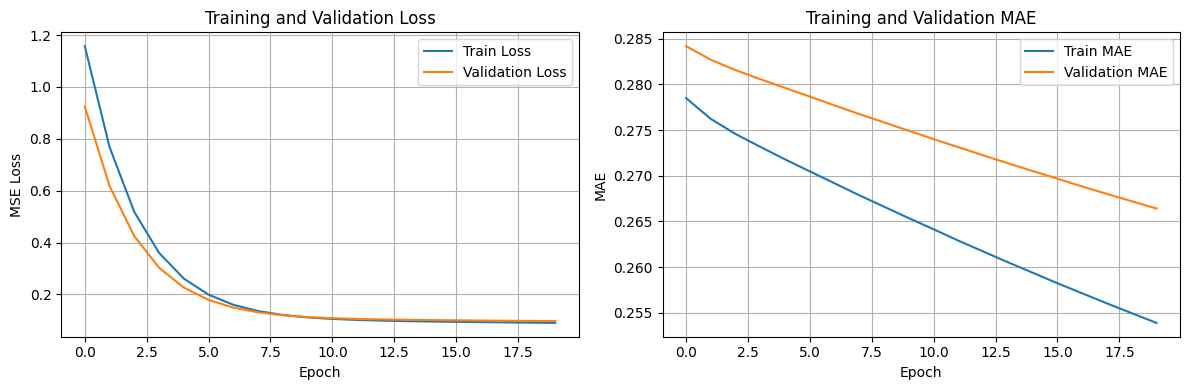

In [17]:
# ====================
# Plot Training History
# ====================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training and Validation MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [18]:
# ===========================
# Evaluate on Test Data
# ===========================
from sklearn.metrics import mean_squared_error, mean_absolute_error

test_loss, test_mae = model.evaluate(X_test, y_test, verbose=1)

y_pred = model.predict(X_test, verbose=0).flatten()
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "="*50)
print("MODEL EVALUATION METRICS")
print("="*50)
print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print("="*50)

# Save metrics to file
import os
os.makedirs("../results", exist_ok=True)

metrics_text = (
    f"Matrix Factorization Model Evaluation - Pranathi Dataset\n"
    f"=====================================\n"
    f"Test Loss (MSE): {test_loss:.4f}\n"
    f"Test MAE: {test_mae:.4f}\n"
    f"Test RMSE: {rmse:.4f}\n"
    f"\n"
    f"Dataset Info:\n"
    f"- Total users: {num_users}\n"
    f"- Total items: {num_items}\n"
    f"- Training samples: {len(train_df)}\n"
    f"- Test samples: {len(test_df)}\n"
    f"- Embedding size: {embedding_size}\n"
)

with open("../results/metrics_mf_pranathi.txt", "w") as f:
    f.write(metrics_text)

print("\nMetrics saved to: ../results/metrics_mf_pranathi.txt")


46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0971 - mae: 0.2664

MODEL EVALUATION METRICS
Test Loss (MSE): 0.0971
Test MAE: 0.2664
Test RMSE: 0.3116

Metrics saved to: ../results/metrics_mf_pranathi.txt


In [19]:
# ===============
# Test Prediction
# ===============
# Let's predict rating for a specific user-item pair

# Get a random user and item from the test set
sample_idx = np.random.randint(0, len(test_df))
sample_row = test_df.iloc[sample_idx]

user_id_original = sample_row['userId']
item_id_original = sample_row['itemId']
actual_rating = sample_row['rating']

user_enc = user2user_encoded[user_id_original]
item_enc = item2item_encoded[item_id_original]

# Predict
pred_scaled = model.predict([np.array([user_enc]), np.array([item_enc])], verbose=0)[0][0]

# Convert back to original rating scale
pred_original = scaler.inverse_transform([[pred_scaled]])[0][0]
actual_original = scaler.inverse_transform([[actual_rating]])[0][0]

print("Sample Prediction:")
print("="*50)
print(f"User ID: {user_id_original}")
print(f"Item ID: {item_id_original}")
print(f"\nActual rating (scaled 0-1): {actual_rating:.3f}")
print(f"Predicted rating (scaled 0-1): {pred_scaled:.3f}")
print(f"\nActual rating (original scale): {actual_original:.2f}")
print(f"Predicted rating (original scale): {pred_original:.2f}")
print(f"\nAbsolute error: {abs(pred_original - actual_original):.2f}")


Sample Prediction:
User ID: 139.0
Item ID: 82.0

Actual rating (scaled 0-1): 0.750
Predicted rating (scaled 0-1): 0.383

Actual rating (original scale): 4.00
Predicted rating (original scale): 2.53

Absolute error: 1.47


In [20]:
# ===============
# Recommender Function
# ===============
def recommend_items(user_id_original, model, user2user_encoded, item2item_encoded, 
                   itemencoded2item, train_df, num_items, top_n=10):
    """
    Recommend top N items for a given user
    
    Args:
        user_id_original: Original user ID from the dataset
        model: Trained Matrix Factorization model
        user2user_encoded: Dictionary mapping original user IDs to encoded IDs
        item2item_encoded: Dictionary mapping original item IDs to encoded IDs
        itemencoded2item: Dictionary mapping encoded IDs to original item IDs
        train_df: Training dataframe
        num_items: Total number of items
        top_n: Number of recommendations to return
    
    Returns:
        List of recommended item IDs with predicted ratings
    """
    # Check if user exists
    if user_id_original not in user2user_encoded:
        print(f"User {user_id_original} not found in the dataset!")
        return []
    
    # Encode user
    user_enc = user2user_encoded[user_id_original]
    
    # All encoded items
    all_item_ids = np.arange(num_items)
    
    # Items the user has already rated in training
    items_rated = train_df[train_df['user'] == user_enc]['item'].values
    
    # Candidate items (unseen by user)
    items_to_predict = np.setdiff1d(all_item_ids, items_rated)
    
    if len(items_to_predict) == 0:
        print(f"User {user_id_original} has already rated all items!")
        return []
    
    # Prepare input arrays
    user_array = np.full(len(items_to_predict), user_enc)
    
    # Predict scores
    preds = model.predict([user_array, items_to_predict], verbose=0).flatten()
    
    # Sort by predicted score
    top_indices = items_to_predict[np.argsort(preds)[::-1][:top_n]]
    top_scores = preds[np.argsort(preds)[::-1][:top_n]]
    
    # Map back to original item IDs
    recommendations = []
    for item_enc, score in zip(top_indices, top_scores):
        item_id_original = itemencoded2item[item_enc]
        # Convert score back to original scale
        score_original = scaler.inverse_transform([[score]])[0][0]
        recommendations.append((item_id_original, score, score_original))
    
    return recommendations

print("Recommender function defined!")


Recommender function defined!


In [21]:
# ===============================
# Generate Recommendations
# ===============================
# Let's get recommendations for a random user

# Pick a random user from the dataset
sample_user = np.random.choice(list(user2user_encoded.keys()))

print(f"Generating recommendations for User {sample_user}")
print("="*50)

# Get user's existing ratings from training set
user_enc = user2user_encoded[sample_user]
user_history = train_df[train_df['user'] == user_enc][['itemId', 'rating']].head(10)

print(f"\nUser {sample_user}'s rating history (sample):")
if len(user_history) > 0:
    for idx, row in user_history.iterrows():
        rating_original = scaler.inverse_transform([[row['rating']]])[0][0]
        print(f"  Item {row['itemId']}: Rating {rating_original:.2f}")
else:
    print("  No rating history in training set")

# Generate recommendations
recommendations = recommend_items(
    user_id_original=sample_user,
    model=model,
    user2user_encoded=user2user_encoded,
    item2item_encoded=item2item_encoded,
    itemencoded2item=itemencoded2item,
    train_df=train_df,
    num_items=num_items,
    top_n=10
)

print(f"\nTop 10 Recommended Items for User {sample_user}:")
print("="*50)
for i, (item_id, score_scaled, score_original) in enumerate(recommendations, 1):
    print(f"{i:2d}. Item {item_id:4d} | Predicted Rating: {score_original:.2f} (scaled: {score_scaled:.3f})")


Generating recommendations for User 125

User 125's rating history (sample):
  Item 200.0: Rating 3.00
  Item 264.0: Rating 2.00
  Item 55.0: Rating 1.00
  Item 268.0: Rating 3.00
  Item 207.0: Rating 4.00
  Item 202.0: Rating 1.00
  Item 232.0: Rating 1.00
  Item 65.0: Rating 1.00
  Item 284.0: Rating 1.00
  Item 177.0: Rating 2.00

Top 10 Recommended Items for User 125:
 1. Item    0 | Predicted Rating: 3.21 (scaled: 0.554)
 2. Item  252 | Predicted Rating: 3.14 (scaled: 0.534)
 3. Item  120 | Predicted Rating: 3.11 (scaled: 0.526)
 4. Item   62 | Predicted Rating: 3.02 (scaled: 0.505)
 5. Item  193 | Predicted Rating: 2.99 (scaled: 0.499)
 6. Item  297 | Predicted Rating: 2.99 (scaled: 0.496)
 7. Item  114 | Predicted Rating: 2.96 (scaled: 0.489)
 8. Item   80 | Predicted Rating: 2.95 (scaled: 0.487)
 9. Item  121 | Predicted Rating: 2.95 (scaled: 0.487)
10. Item   87 | Predicted Rating: 2.95 (scaled: 0.487)


In [22]:
# ===============================
# Get Recommendations for Specific User
# ===============================
# You can change this to any user ID from your dataset

# Enter your user ID here
my_user_id = 0  # Change this to any user ID in your dataset

print(f"Getting recommendations for User {my_user_id}...\n")

recommendations = recommend_items(
    user_id_original=my_user_id,
    model=model,
    user2user_encoded=user2user_encoded,
    item2item_encoded=item2item_encoded,
    itemencoded2item=itemencoded2item,
    train_df=train_df,
    num_items=num_items,
    top_n=20  # Get top 20 recommendations
)

if recommendations:
    print(f"Top 20 Recommended Items for User {my_user_id}:")
    print("="*60)
    for i, (item_id, score_scaled, score_original) in enumerate(recommendations, 1):
        print(f"{i:2d}. Item {item_id:4d} | Predicted Rating: {score_original:.2f}")


Getting recommendations for User 0...

Top 20 Recommended Items for User 0:
 1. Item    0 | Predicted Rating: 3.51
 2. Item  120 | Predicted Rating: 3.40
 3. Item   62 | Predicted Rating: 3.32
 4. Item  193 | Predicted Rating: 3.30
 5. Item  297 | Predicted Rating: 3.29
 6. Item  114 | Predicted Rating: 3.26
 7. Item   80 | Predicted Rating: 3.25
 8. Item  121 | Predicted Rating: 3.25
 9. Item   87 | Predicted Rating: 3.25
10. Item  103 | Predicted Rating: 3.25
11. Item  147 | Predicted Rating: 3.24
12. Item  200 | Predicted Rating: 3.24
13. Item   51 | Predicted Rating: 3.24
14. Item    2 | Predicted Rating: 3.23
15. Item  199 | Predicted Rating: 3.23
16. Item   85 | Predicted Rating: 3.23
17. Item  267 | Predicted Rating: 3.23
18. Item  138 | Predicted Rating: 3.23
19. Item  107 | Predicted Rating: 3.22
20. Item  155 | Predicted Rating: 3.22


In [23]:
# ===============================
# Model Summary and Information
# ===============================
print("\n" + "="*60)
print("MATRIX FACTORIZATION MODEL SUMMARY")
print("="*60)
print(f"Dataset: Pranathi Custom Data")
print(f"Total Users: {num_users}")
print(f"Total Items: {num_items}")
print(f"Total Interactions: {len(ratings)}")
print(f"\nTraining Samples: {len(train_df)}")
print(f"Test Samples: {len(test_df)}")
print(f"\nEmbedding Size: {embedding_size}")
print(f"Regularization Strength: {reg_strength}")
print(f"\nTest MSE: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print("="*60)
print("\nModel saved as: mf_pranathi_best_model.keras")
print("Metrics saved as: ../results/metrics_mf_pranathi.txt")



MATRIX FACTORIZATION MODEL SUMMARY
Dataset: Pranathi Custom Data
Total Users: 290
Total Items: 300
Total Interactions: 6960

Training Samples: 5510
Test Samples: 1450

Embedding Size: 32
Regularization Strength: 0.01

Test MSE: 0.0971
Test MAE: 0.2664
Test RMSE: 0.3116

Model saved as: mf_pranathi_best_model.keras
Metrics saved as: ../results/metrics_mf_pranathi.txt
